In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("../data/donors.csv")

df.head()

,donor_id,author,source_url,license,behaviour_family,family_size,family_evidence,main_py_sha256,size_bytes,payload_included,payload_format,payload_b64,verified
0,ahmedberatozer-v27,Ahmed Berat Özer (ahmedberatozer),Ahmed Berat Özer's v27 notebook (slug not reco...,Apache-2.0 (notices retained in source) / Kagg...,F??,1,not yet measured in an arena pass,f9db9c4e4114bc956752b90df35d0c7ceda96e5009573f...,172431,True,py,IyBOZXcgYWN0aW9uIHRhcGVzIGFuZCBvcmRlcmVkIHNob3...,"2026-09-14: seed 11 vs IDLE, bank 90,252 from ..."
1,ahmedberatozer-v31-production-and-sale-priority,Ahmed Berat Özer (ahmedberatozer),https://www.kaggle.com/code/ahmedberatozer/kag...,Apache-2.0 (notices retained in source) / Kagg...,F??,1,not yet measured in an arena pass,3a72da1f2b3b31386366988408503f01581c2855291373...,235111,True,py,IyBLYWdncmljdWx0dXJlIHYzMSAvIEVYUC0xNTcsIEFobW...,"2026-09-14: seed 11 vs IDLE, bank 90,621 from ..."
2,ahmedberatozer-v34-observed-market-timing,ahmedberatozer,https://www.kaggle.com/code/ahmedberatozer/kag...,Kaggle notebook default (Apache 2.0); attribut...,F04,1,unique bank vector,58f3cbf957c267b464ec0bcfdc9ba7940f708e6ae77c72...,254081,True,py,IyBLYWdncmljdWx0dXJlIEVYUC0xNjcgY2FuZGlkYXRlLi...,"2026-09-14: seed 11 vs IDLE, bank 90,322 from ..."
3,ahmedberatozer-v35-reactive-sales-sheep-expansion,ahmedberatozer,https://www.kaggle.com/code/ahmedberatozer/kag...,Kaggle notebook default (Apache 2.0); attribut...,F05,1,unique bank vector,294e7e4d9d4b97413646960d318043e0f9116ce58f42fe...,267230,True,py,IyBFWFAtMTczIGlzb2xhdGUgb3BlbmluZyBtYXJrZXQgc2...,"2026-09-14: seed 11 vs IDLE, bank 90,322 from ..."
4,ahmedberatozer-v36-guarded-four-turn-sales,ahmedberatozer,https://www.kaggle.com/code/ahmedberatozer/kag...,Kaggle notebook default (Apache 2.0); attribut...,F06,1,unique bank vector,7eb5ab6c48581c82906ab6fa6b2cc5c9607513249ef59b...,267360,True,py,IyBFWFAtMTczIGlzb2xhdGUgb3BlbmluZyBtYXJrZXQgc2...,"2026-09-14: seed 11 vs IDLE, bank 90,230 from ..."


In [ ]:
df.shape

In [3]:
y = df["size_bytes"]

In [4]:
X = df.drop(columns=["size_bytes"])
X = X.select_dtypes(include="number")

print(X.columns)

Index(['family_size'], dtype='str')


In [5]:
print("Признаки:", X.columns.tolist())
print("Количество признаков:", X.shape[1])

Признаки: ['family_size']
Количество признаков: 1


In [6]:
X = df.drop(columns=["size_bytes"])
X = X.select_dtypes(include="number")

print(X.columns)
print(X.shape)

Index(['family_size'], dtype='str')
(52, 1)


In [7]:
import pandas as pd

df = pd.read_csv("../data/insurance.csv")

df.head()

,age,weight,height,income_lpa,smoker,city,occupation,insurance_premium_category
0,67,119.8,1.56,2.92,False,Jaipur,retired,High
1,36,101.1,1.83,34.28,False,Chennai,freelancer,Low
2,39,56.8,1.64,36.64,False,Indore,freelancer,Low
3,22,109.4,1.55,3.34,True,Mumbai,student,Medium
4,69,62.2,1.60,3.94,True,Indore,retired,High


In [8]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(100, 8)
age                             int64
weight                        float64
height                        float64
income_lpa                    float64
smoker                           bool
city                              str
occupation                        str
insurance_premium_category        str
dtype: object
age                           0
weight                        0
height                        0
income_lpa                    0
smoker                        0
city                          0
occupation                    0
insurance_premium_category    0
dtype: int64


In [9]:
df.head(10)

,age,weight,height,income_lpa,smoker,city,occupation,insurance_premium_category
0,67,119.8,1.56,2.920000,False,Jaipur,retired,High
1,36,101.1,1.83,34.280000,False,Chennai,freelancer,Low
2,39,56.8,1.64,36.640000,False,Indore,freelancer,Low
3,22,109.4,1.55,3.340000,True,Mumbai,student,Medium
4,69,62.2,1.60,3.940000,True,Indore,retired,High
5,53,62.9,1.66,50.000000,False,Kota,freelancer,Medium
6,19,80.1,1.68,3.590000,True,Hyderabad,student,Medium
7,31,105.7,1.78,10.865821,True,Delhi,government_job,Medium
8,73,58.0,1.58,1.780000,False,Chandigarh,retired,Medium
9,58,74.4,1.73,43.070000,False,Pune,business_owner,Low


In [10]:
print(df["insurance_premium_category"].unique())
print(df["insurance_premium_category"].value_counts())

<StringArray>
['High', 'Low', 'Medium']
Length: 3, dtype: str
insurance_premium_category
Low       34
High      33
Medium    33
Name: count, dtype: int64


In [11]:
df.describe()

,age,weight,height,income_lpa
count,100.000000,100.000000,100.000000,100.000000
mean,47.180000,83.894000,1.713200,18.400600
std,16.649312,21.020278,0.110205,16.067465
min,18.000000,51.100000,1.500000,0.530000
25%,34.750000,63.650000,1.610000,2.897500
50%,47.000000,82.300000,1.730000,14.122583
75%,61.000000,101.300000,1.810000,30.162500
max,75.000000,119.800000,1.900000,50.000000


In [12]:
print(df["insurance_premium_category"].unique())

<StringArray>
['High', 'Low', 'Medium']
Length: 3, dtype: str


In [13]:
import pandas as pd

df = pd.read_csv("../data/insurance.csv")

print(df.shape)
print(df.dtypes)
df.head()

(100, 8)
age                             int64
weight                        float64
height                        float64
income_lpa                    float64
smoker                           bool
city                              str
occupation                        str
insurance_premium_category        str
dtype: object


,age,weight,height,income_lpa,smoker,city,occupation,insurance_premium_category
0,67,119.8,1.56,2.92,False,Jaipur,retired,High
1,36,101.1,1.83,34.28,False,Chennai,freelancer,Low
2,39,56.8,1.64,36.64,False,Indore,freelancer,Low
3,22,109.4,1.55,3.34,True,Mumbai,student,Medium
4,69,62.2,1.60,3.94,True,Indore,retired,High


In [14]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.head()

(100, 8)
age                             int64
weight                        float64
height                        float64
income_lpa                    float64
smoker                           bool
city                              str
occupation                        str
insurance_premium_category        str
dtype: object
age                           0
weight                        0
height                        0
income_lpa                    0
smoker                        0
city                          0
occupation                    0
insurance_premium_category    0
dtype: int64


,age,weight,height,income_lpa,smoker,city,occupation,insurance_premium_category
0,67,119.8,1.56,2.92,False,Jaipur,retired,High
1,36,101.1,1.83,34.28,False,Chennai,freelancer,Low
2,39,56.8,1.64,36.64,False,Indore,freelancer,Low
3,22,109.4,1.55,3.34,True,Mumbai,student,Medium
4,69,62.2,1.60,3.94,True,Indore,retired,High


In [15]:
X = df.drop(columns=["charges"])
y = df["charges"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

KeyError: "['charges'] not found in axis"

In [20]:
print(df.columns.tolist())

['age', 'weight', 'height', 'income_lpa', 'smoker', 'city', 'occupation', 'insurance_premium_category']


In [21]:
import pandas as pd

df = pd.read_csv("../data/insurance.csv")

print(df.columns.tolist())

['age', 'weight', 'height', 'income_lpa', 'smoker', 'city', 'occupation', 'insurance_premium_category']


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (41, 1)
Test: (11, 1)


In [ ]:
X = df.drop(columns=["charges"])
y = df["charges"]

print("Features:", X.columns.tolist())
print("Target:", y.name)

KeyError: "['charges'] not found in axis"

: 

In [17]:
numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['age', 'bmi', 'children']
Categorical: ['sex', 'smoker', 'region']


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [19]:
from sklearn.linear_model import LinearRegression

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

baseline_model.fit(X_train, y_train)

ValueError: Some column names are not columns of the dataframe: {'children', 'age', 'bmi'}

In [1]:
print(df.columns.tolist())

NameError: name 'df' is not defined

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/insurance.csv")

In [4]:
print(df.shape)
print(df.columns.tolist())
df.head()

(100, 8)
['age', 'weight', 'height', 'income_lpa', 'smoker', 'city', 'occupation', 'insurance_premium_category']


,age,weight,height,income_lpa,smoker,city,occupation,insurance_premium_category
0,67,119.8,1.56,2.92,False,Jaipur,retired,High
1,36,101.1,1.83,34.28,False,Chennai,freelancer,Low
2,39,56.8,1.64,36.64,False,Indore,freelancer,Low
3,22,109.4,1.55,3.34,True,Mumbai,student,Medium
4,69,62.2,1.60,3.94,True,Indore,retired,High


In [5]:
print(df.columns.tolist())

['age', 'weight', 'height', 'income_lpa', 'smoker', 'city', 'occupation', 'insurance_premium_category']


In [6]:
import os

print(os.listdir("../data"))

['donors.csv', 'insurance.csv']


In [7]:
import pandas as pd

df = pd.read_csv("../data/medical_insurance.csv")

print(df.shape)
print(df.columns.tolist())
df.head()

(1338, 7)
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [9]:
X = df.drop(columns=["charges"])
y = df["charges"]

print("Features:", X.columns.tolist())
print("Target:", y.name)

Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
Target: charges


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1070, 6)
Test: (268, 6)


In [11]:
numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['age', 'bmi', 'children']
Categorical: ['sex', 'smoker', 'region']


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

In [13]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [14]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [15]:
y_pred = baseline_model.predict(X_test)

print(y_pred[:10])

NameError: name 'baseline_model' is not defined

In [16]:
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")

NameError: name 'y_pred' is not defined

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

In [19]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [18]:
numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

In [20]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [21]:
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the 

In [22]:
y_pred = baseline_model.predict(X_test)

print(y_pred[:10])

[ 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656 10864.11316424   170.28084136 16903.45028662
  1092.43093614 11218.34318352]


In [23]:
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_base = mean_absolute_error(y_test, y_pred)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred))
r2_base = r2_score(y_test, y_pred)

print(f"MAE:  {mae_base:.2f}")
print(f"RMSE: {rmse_base:.2f}")
print(f"R²:   {r2_base:.3f}")

MAE:  4181.19
RMSE: 5796.28
R²:   0.784


In [24]:
numeric_data = X_train[["age", "bmi", "children"]]

correlation_matrix = numeric_data.corr()

correlation_matrix

,age,bmi,children
age,1.000000,0.118274,0.060999
bmi,0.118274,1.000000,-0.005040
children,0.060999,-0.005040,1.000000


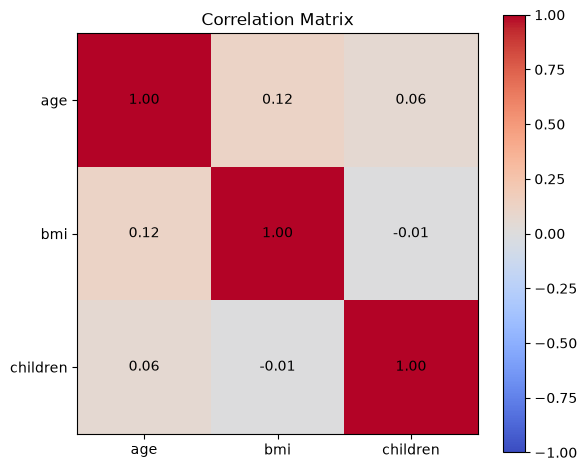

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))

ax.set_xticklabels(correlation_matrix.columns)
ax.set_yticklabels(correlation_matrix.columns)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(im)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [26]:
correlation_matrix

,age,bmi,children
age,1.000000,0.118274,0.060999
bmi,0.118274,1.000000,-0.005040
children,0.060999,-0.005040,1.000000


In [27]:
reduced_numeric_features = ["age", "bmi"]

reduced_preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, reduced_numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

reduced_model = Pipeline([
    ("preprocessor", reduced_preprocessor),
    ("model", LinearRegression())
])

reduced_model.fit(X_train, y_train)

y_pred_reduced = reduced_model.predict(X_test)

In [28]:
mae_reduced = mean_absolute_error(y_test, y_pred_reduced)
rmse_reduced = np.sqrt(mean_squared_error(y_test, y_pred_reduced))
r2_reduced = r2_score(y_test, y_pred_reduced)

print("BASELINE MODEL")
print(f"MAE:  {mae_base:.2f}")
print(f"RMSE: {rmse_base:.2f}")
print(f"R²:   {r2_base:.3f}")

print("\nREDUCED MODEL")
print(f"MAE:  {mae_reduced:.2f}")
print(f"RMSE: {rmse_reduced:.2f}")
print(f"R²:   {r2_reduced:.3f}")

BASELINE MODEL
MAE:  4181.19
RMSE: 5796.28
R²:   0.784

REDUCED MODEL
MAE:  4222.91
RMSE: 5843.15
R²:   0.780


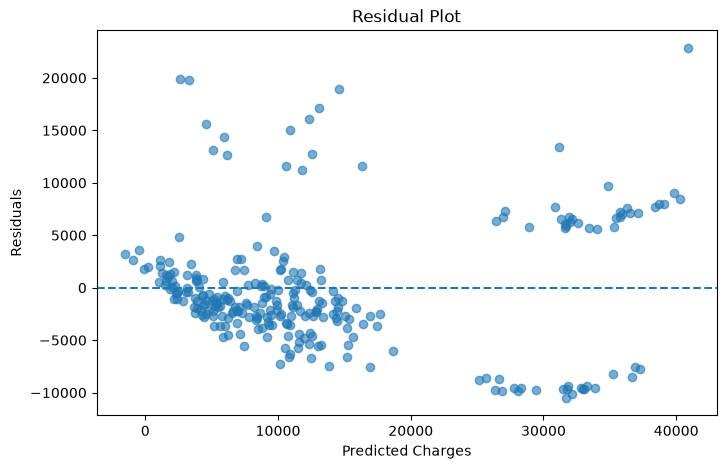

In [29]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

Анализ остатков:
На графике остатки распределены вокруг нулевой линии не полностью случайно. Видны отдельные группы и систематические отклонения, особенно при больших прогнозируемых значениях charges. Это указывает на то, что линейная модель не полностью описывает зависимости в данных и некоторые допущения линейной регрессии могут нарушаться.

Анализ остатков:
На графике остатки распределены вокруг нулевой линии не полностью случайно. Видны отдельные группы и систематические отклонения, особенно при больших прогнозируемых значениях charges. Это указывает на то, что линейная модель не полностью описывает зависимости в данных и некоторые допущения линейной регрессии могут нарушаться.

In [30]:
# Практическая работа — Сравнение наборов признаков

## 1. Загрузка данных
## 2. Разделение на train/test
## 3. Предобработка данных
## 4. Базовая модель
## 5. Метрики базовой модели
## 6. Проверка мультиколлинеарности
## 7. Сокращённый набор признаков
## 8. Сравнение моделей
## 9. Анализ остатков
## 10. Вывод

In [31]:
results = pd.DataFrame({
    "Model": ["Baseline", "Reduced"],
    "MAE": [mae_base, mae_reduced],
    "RMSE": [rmse_base, rmse_reduced],
    "R2": [r2_base, r2_reduced]
})

results

,Model,MAE,RMSE,R2
0,Baseline,4181.194474,5796.284659,0.783593
1,Reduced,4222.908402,5843.146824,0.780080


## Вывод

Была обучена модель линейной регрессии для прогнозирования медицинских расходов `charges`.

Для предобработки использовались Pipeline и ColumnTransformer. Разделение данных на train/test было выполнено до обучения пайплайна.

Корреляционный анализ не выявил сильной мультиколлинеарности между числовыми признаками. Максимальная корреляция составила 0.12 между `age` и `bmi`.

Базовая модель:
- MAE = 4181.19
- RMSE = 5796.28
- R² = 0.784

После удаления признака `children`:
- MAE = 4222.91
- RMSE = 5843.15
- R² = 0.780

После удаления `children` качество модели немного ухудшилось. Поэтому финальная модель использует полный набор признаков: `age`, `bmi`, `children`, `sex`, `smoker`, `region`.

График остатков показывает систематические паттерны, особенно при больших прогнозируемых значениях. Это говорит о том, что линейная регрессия не полностью описывает зависимости в данных.